# HumanForYou - Exploration des données

HumanForYou est une entreprise pharmaceutique d'environ 4400 employés qui perd chaque année autour de 15% de ses effectifs. C'est beaucoup. L'objectif de ce projet, c'est de comprendre pourquoi des employés partent et de construire un modèle capable de prédire qui risque de quitter l'entreprise.

On commence par explorer les données avant de toucher quoi que ce soit. C'est indispensable pour comprendre ce qu'on a entre les mains et éviter de faire n'importe quoi dans les étapes suivantes.

## Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

RAW = '../data/raw/'

## 1. Chargement

On a 5 fichiers à disposition. L'idée c'est de les fusionner ensuite sur l'identifiant employé.

In [2]:
general  = pd.read_csv(RAW + 'general_data.csv')
survey   = pd.read_csv(RAW + 'employee_survey_data.csv')
manager  = pd.read_csv(RAW + 'manager_survey_data.csv')
in_time  = pd.read_csv(RAW + 'in_time.csv', index_col=0)
out_time = pd.read_csv(RAW + 'out_time.csv', index_col=0)

print(f"general_data    : {general.shape}")
print(f"employee_survey : {survey.shape}")
print(f"manager_survey  : {manager.shape}")
print(f"in_time         : {in_time.shape}")
print(f"out_time        : {out_time.shape}")

general_data    : (4410, 24)
employee_survey : (4410, 4)
manager_survey  : (4410, 3)
in_time         : (4410, 261)
out_time        : (4410, 261)


## 2. Aperçu rapide

On jette un oeil à la structure et aux types de colonnes.

In [3]:
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,...,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,...,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,...,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,...,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,...,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,...,4.0,Y,12,8,2,9.0,2,6,0,4


In [4]:
general.info()

<class 'pandas.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 24 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   str    
 2   BusinessTravel           4410 non-null   str    
 3   Department               4410 non-null   str    
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   str    
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   str    
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   str    
 12  MaritalStatus            4410 non-null   str    
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked       4391 non-n

In [5]:
general.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,4410.0,NaN,NaN,NaN,36.92381,9.133301,18.0,30.0,36.0,43.0,60.0
Attrition,4410,2,No,3699,NaN,NaN,NaN,NaN,NaN,NaN,NaN
BusinessTravel,4410,3,Travel_Rarely,3129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Department,4410,3,Research & Development,2883,NaN,NaN,NaN,NaN,NaN,NaN,NaN
DistanceFromHome,4410.0,NaN,NaN,NaN,9.192517,8.105026,1.0,2.0,7.0,14.0,29.0
Education,4410.0,NaN,NaN,NaN,2.912925,1.023933,1.0,2.0,3.0,4.0,5.0
EducationField,4410,6,Life Sciences,1818,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EmployeeCount,4410.0,NaN,NaN,NaN,1.0,0.0,1.0,1.0,1.0,1.0,1.0
EmployeeID,4410.0,NaN,NaN,NaN,2205.5,1273.201673,1.0,1103.25,2205.5,3307.75,4410.0
Gender,4410,2,Male,2646,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. La variable cible : Attrition

C'est ce qu'on cherche à prédire. "Yes" = l'employé a quitté l'entreprise, "No" = il est resté. On voit directement qu'il y a un déséquilibre : environ 84% de restants pour 16% de partants. Ca va influencer nos choix de modélisation.

In [6]:
attr_counts = general['Attrition'].value_counts()
attr_pct    = general['Attrition'].value_counts(normalize=True) * 100

print(attr_counts)
print()
print(attr_pct.round(1).astype(str) + ' %')

Attrition
No     3699
Yes     711
Name: count, dtype: int64

Attrition
No     83.9 %
Yes    16.1 %
Name: proportion, dtype: str


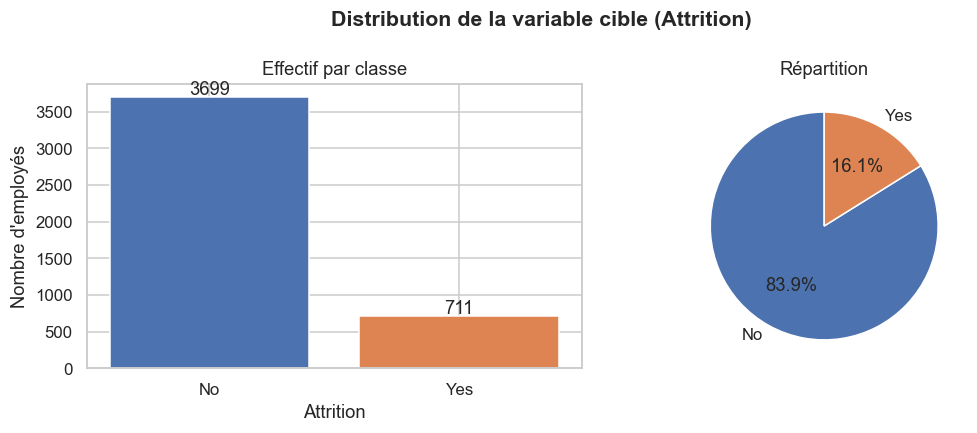


84% restent, 16% partent → déséquilibre à gérer dans la modélisation


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(attr_counts.index, attr_counts.values, color=['#4C72B0', '#DD8452'])
for i, (label, val) in enumerate(zip(attr_counts.index, attr_counts.values)):
    axes[0].text(i, val + 30, str(val), ha='center', fontsize=12)
axes[0].set_title('Effectif par classe')
axes[0].set_xlabel('Attrition')
axes[0].set_ylabel('Nombre d\'employés')

axes[1].pie(attr_counts.values, labels=attr_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0', '#DD8452'], startangle=90)
axes[1].set_title('Répartition')

plt.suptitle('Distribution de la variable cible (Attrition)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/attrition_distribution.png', bbox_inches='tight')
plt.show()

print(f"\n84% restent, 16% partent → déséquilibre à gérer dans la modélisation")

## 4. Colonnes inutiles

Avant de modéliser, on vérifie s'il y a des colonnes qui n'apportent aucune information. Une colonne avec la même valeur pour tout le monde ne peut pas aider un modèle à faire des distinctions.

In [8]:
nunique = general.nunique()
constant_cols = nunique[nunique == 1].index.tolist()
print("Colonnes constantes :", constant_cols)
for col in constant_cols:
    print(f"  {col} → {general[col].unique()}")

Colonnes constantes : ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount → [1]
  Over18 → <StringArray>
['Y']
Length: 1, dtype: str
  StandardHours → [8]


`EmployeeCount`, `Over18` et `StandardHours` ont la même valeur pour les 4410 employés. On les supprime, elles ne servent à rien.

## 5. Valeurs manquantes

On regarde combien de données manquent et dans quelles colonnes.

In [9]:
def missing_summary(df, name):
    na = df.isna().sum()
    na = na[na > 0]
    if na.empty:
        print(f"{name} : pas de NA")
    else:
        pct = (na / len(df) * 100).round(2)
        print(f"\n{name} :")
        for col in na.index:
            print(f"  {col:35s} {na[col]:4d} ({pct[col]:.2f}%)")

missing_summary(general, 'general_data')
missing_summary(survey,  'employee_survey')
missing_summary(manager, 'manager_survey')


general_data :
  NumCompaniesWorked                    19 (0.43%)
  TotalWorkingYears                      9 (0.20%)

employee_survey :
  EnvironmentSatisfaction               25 (0.57%)
  JobSatisfaction                       20 (0.45%)
  WorkLifeBalance                       38 (0.86%)
manager_survey : pas de NA


Peu de NA partout (moins de 1%). On peut se permettre d'imputer plutot que de supprimer des lignes - on perdrait de l'information pour rien. La médiane sera préférée à la moyenne parce qu'elle est moins sensible aux valeurs extrêmes.

## 6. Distributions des variables numériques

On visualise les distributions pour repérer des formes particulières, des valeurs aberrantes, ou des variables qui pourraient être discriminantes.

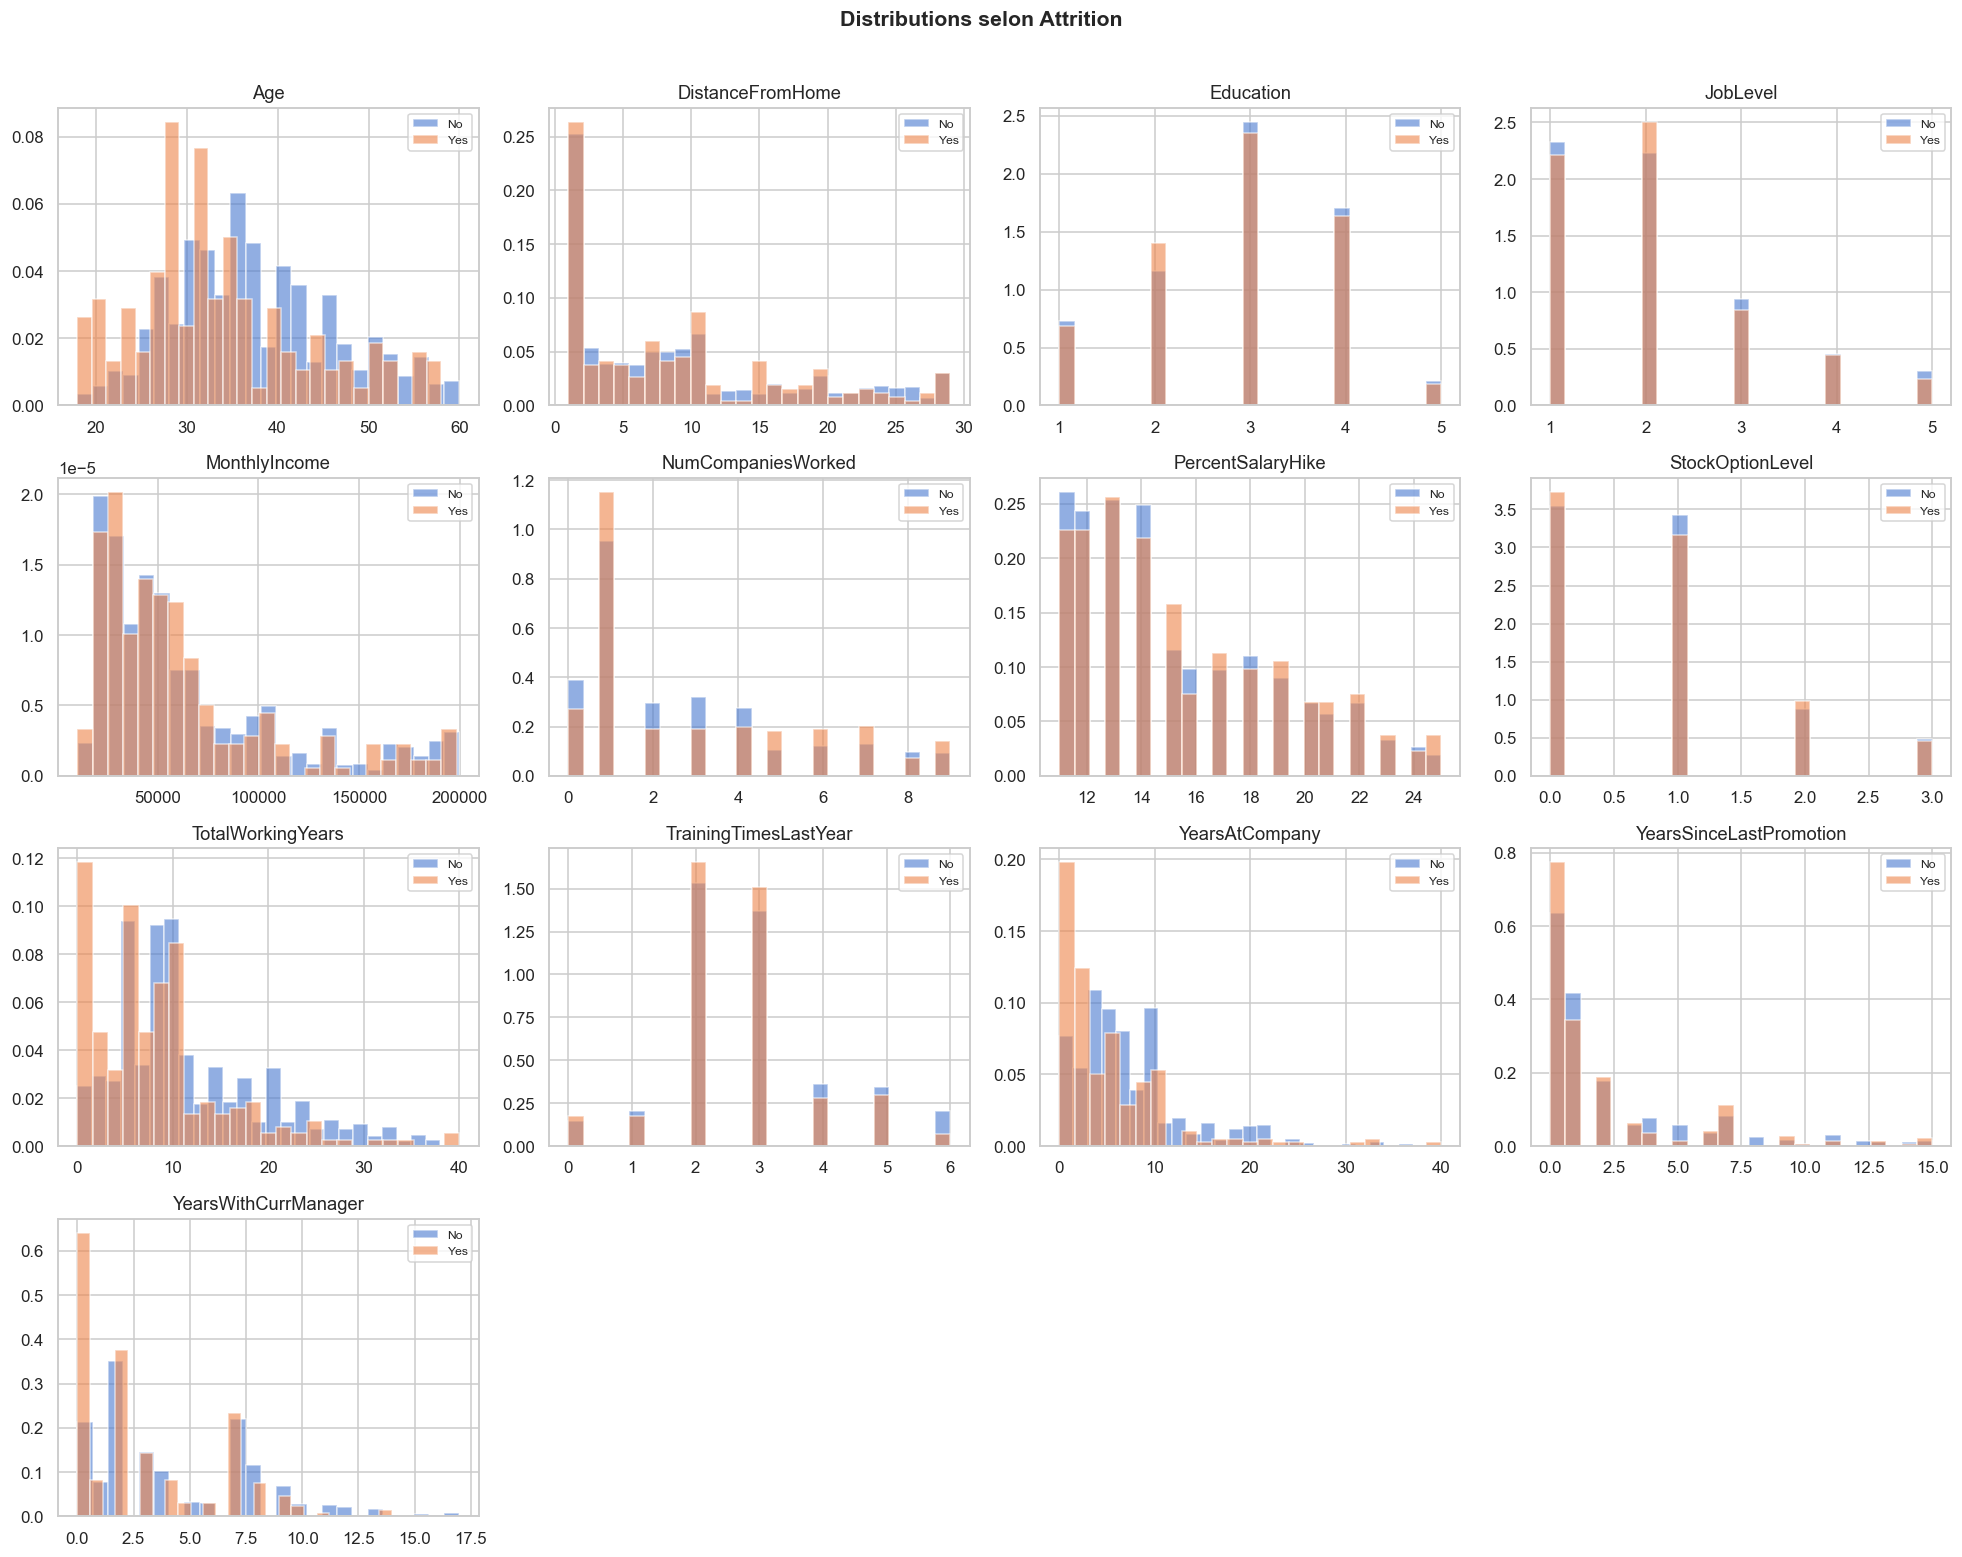

In [10]:
num_cols = general.select_dtypes(include='number').columns.drop(['EmployeeID', 'EmployeeCount', 'StandardHours'])

n_cols = 4
n_rows = -(-len(num_cols) // n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3.5))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    for label, grp in general.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=25, alpha=0.6, label=label, density=True)
    axes[i].set_title(col)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distributions selon Attrition', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/numeric_distributions.png', bbox_inches='tight')
plt.show()

## 7. Variables catégorielles vs Attrition

Pour chaque variable catégorielle, on calcule le taux de départ par modalité. Ca permet de voir si certaines catégories sont plus à risque que d'autres.

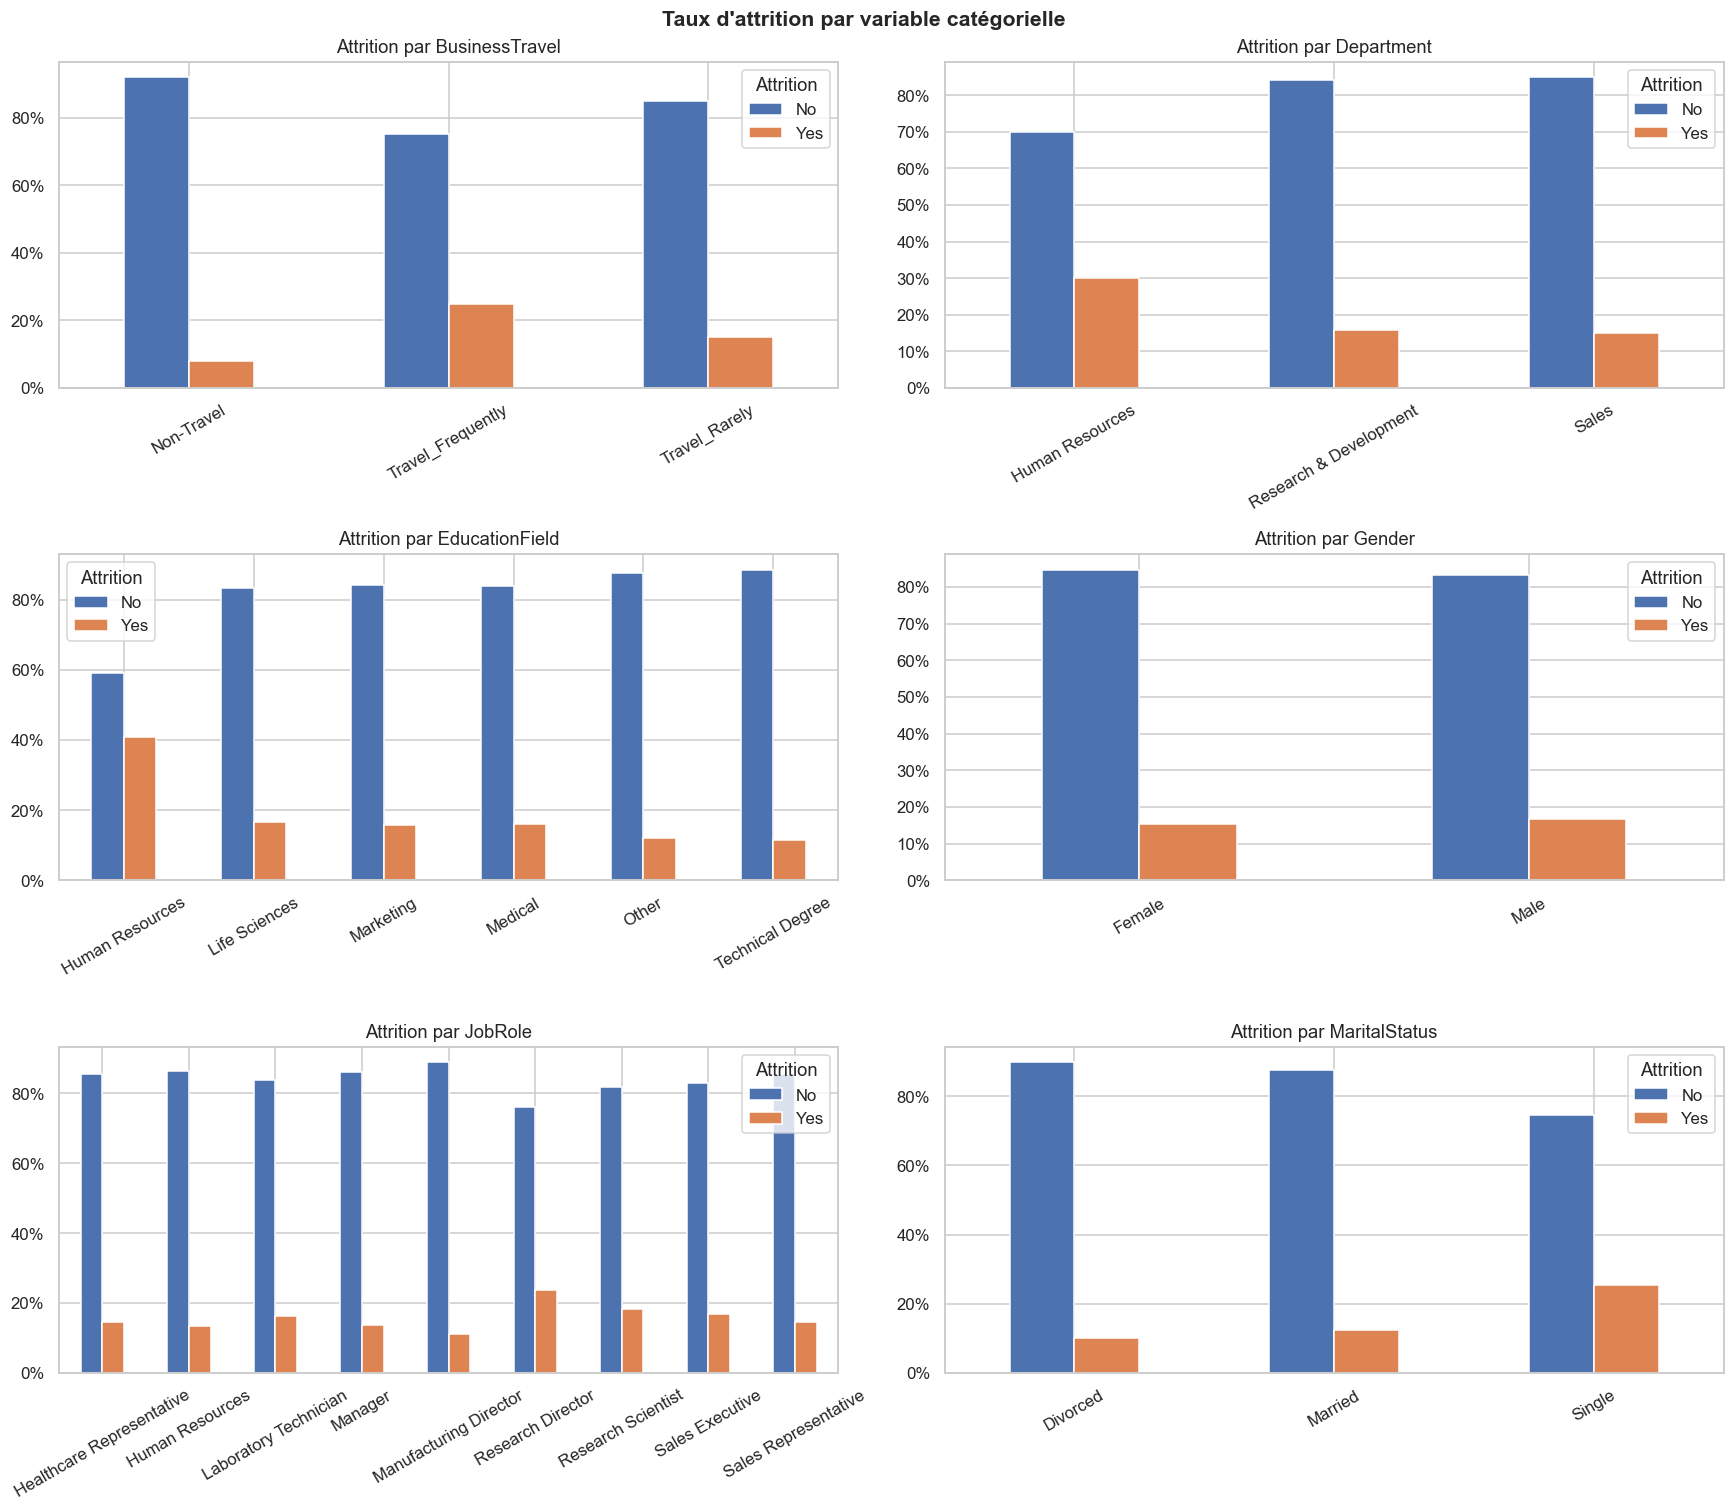

In [11]:
cat_cols = ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    tbl = general.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel('')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=30)
    axes[i].legend(title='Attrition')

plt.suptitle('Taux d\'attrition par variable catégorielle', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/categorical_attrition.png', bbox_inches='tight')
plt.show()

## 8. Satisfaction (enquête employés)

Ces variables viennent d'une enquête de satisfaction interne. Elles sont notées de 1 (faible) à 4 (élevé). On regarde si les scores diffèrent entre partants et restants.

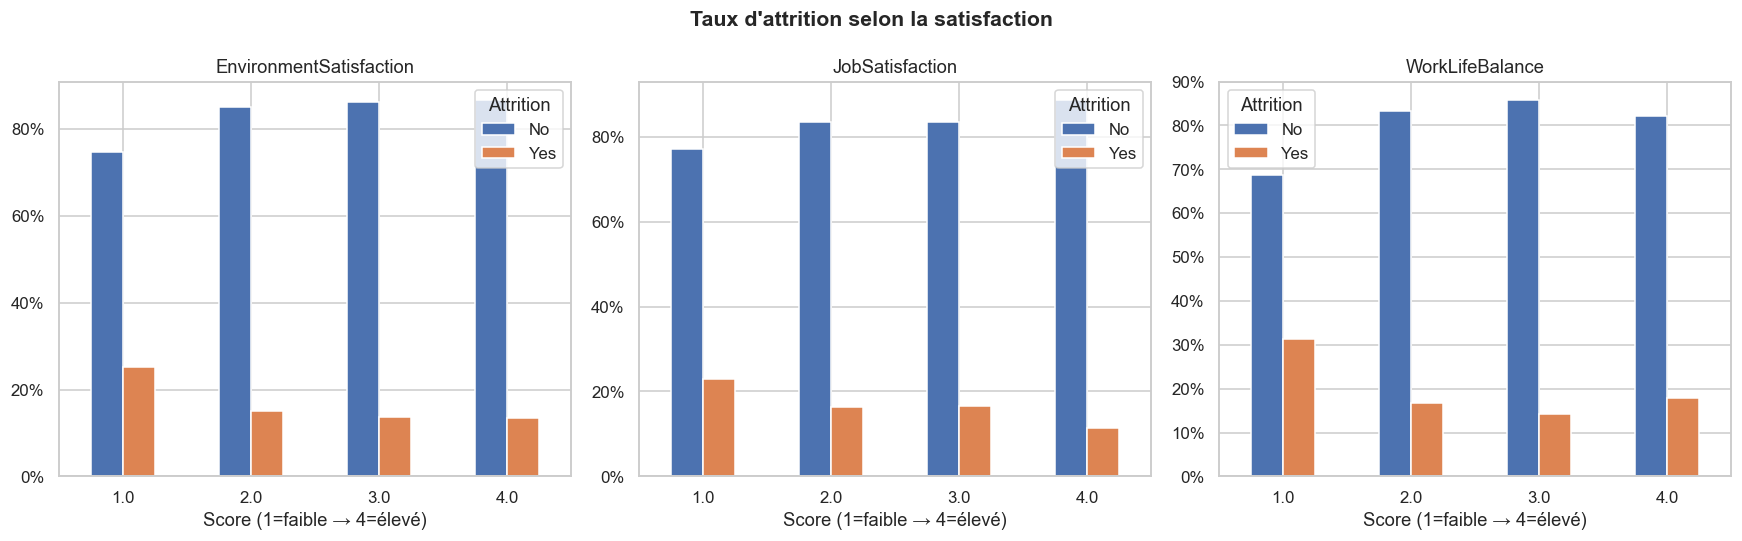

In [12]:
survey_merged = survey.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

sat_cols = ['EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance']

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for i, col in enumerate(sat_cols):
    tbl = survey_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(col)
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')
    axes[i].set_xlabel('Score (1=faible → 4=élevé)')

plt.suptitle('Taux d\'attrition selon la satisfaction', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/satisfaction_attrition.png', bbox_inches='tight')
plt.show()

## 9. Evaluation manager

Deux variables issues de l'évaluation faite par les managers. `PerformanceRating` ne prend que les valeurs 3 et 4 dans nos données - tout le monde est bien noté, ce qui la rend peu utile. `JobInvolvement` est plus intéressante.

JobInvolvement    : [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
PerformanceRating : [np.int64(3), np.int64(4)]
NA : {'EmployeeID': 0, 'JobInvolvement': 0, 'PerformanceRating': 0}


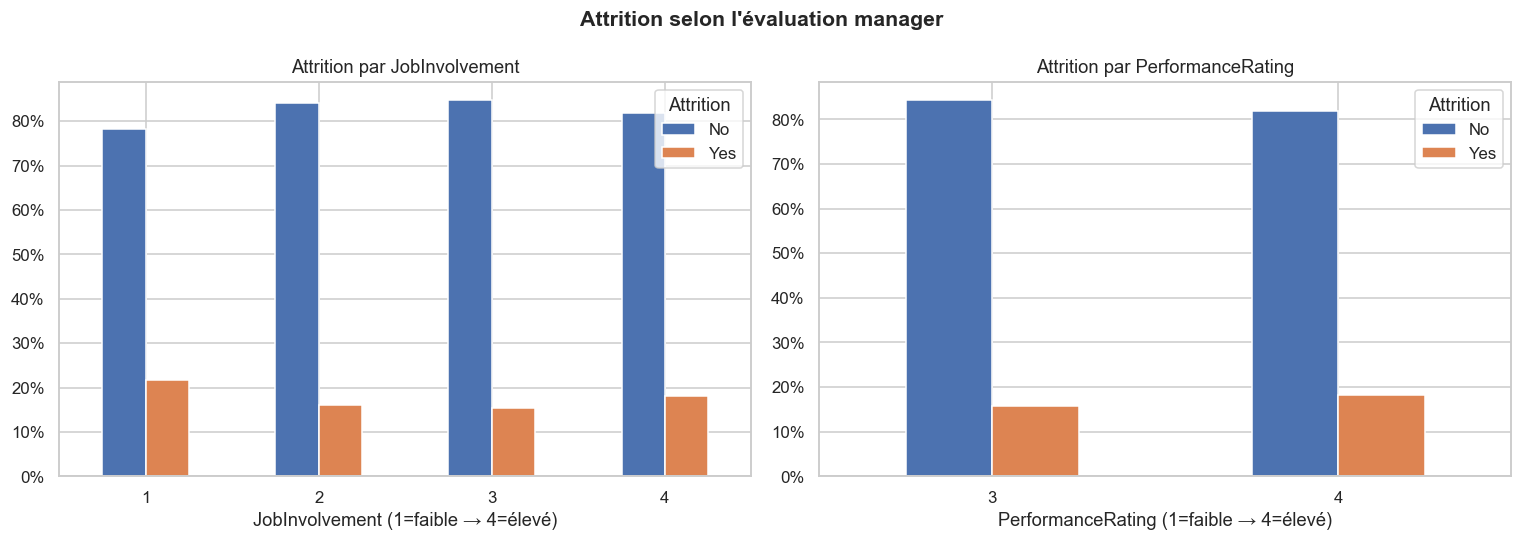


Taux de départ par JobInvolvement :
JobInvolvement
1    21.7
2    16.0
3    15.3
4    18.1


In [13]:
manager_merged = manager.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

print(f"JobInvolvement    : {sorted(manager['JobInvolvement'].unique())}")
print(f"PerformanceRating : {sorted(manager['PerformanceRating'].unique())}")
print(f"NA : {manager.isna().sum().to_dict()}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, col in enumerate(['JobInvolvement', 'PerformanceRating']):
    tbl = manager_merged.groupby([col, 'Attrition']).size().unstack(fill_value=0)
    tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100
    tbl_pct.plot(kind='bar', ax=axes[i], color=['#4C72B0', '#DD8452'], edgecolor='white')
    axes[i].set_title(f'Attrition par {col}')
    axes[i].set_xlabel(f'{col} (1=faible → 4=élevé)')
    axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(title='Attrition')

plt.suptitle("Attrition selon l'évaluation manager", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/manager_survey_attrition.png', bbox_inches='tight')
plt.show()

print("\nTaux de départ par JobInvolvement :")
print(manager_merged.groupby('JobInvolvement')['Attrition']
      .apply(lambda x: (x == 'Yes').mean() * 100).round(1).to_string())

## 10. Corrélations

On regarde les corrélations entre variables numériques pour repérer des liens forts et éviter la redondance.

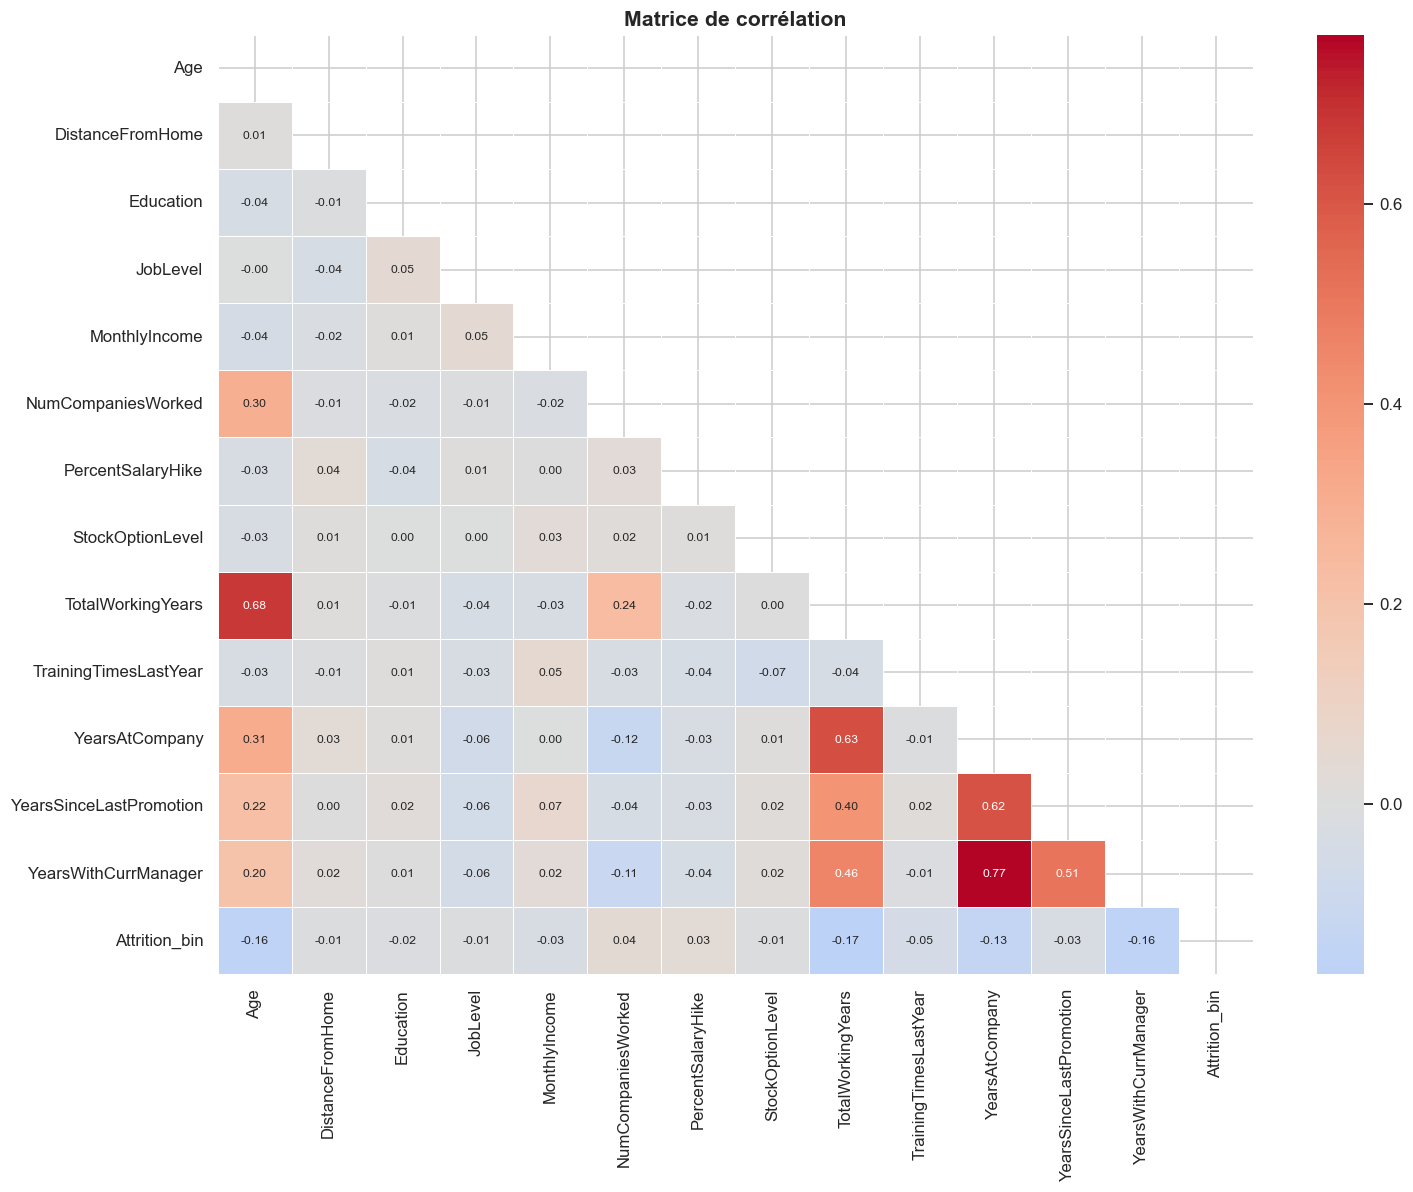

In [14]:
gen_corr = general.copy()
gen_corr['Attrition_bin'] = (gen_corr['Attrition'] == 'Yes').astype(int)

num_corr_cols = list(num_cols) + ['Attrition_bin']
corr_matrix = gen_corr[num_corr_cols].corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, annot_kws={'size': 8})
ax.set_title('Matrice de corrélation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/correlation_matrix.png', bbox_inches='tight')
plt.show()

In [15]:
corr_with_target = corr_matrix['Attrition_bin'].drop('Attrition_bin').sort_values(key=abs, ascending=False)
print("Top corrélations avec Attrition :")
print(corr_with_target.round(3).to_string())

Top corrélations avec Attrition :
TotalWorkingYears         -0.170
Age                       -0.159
YearsWithCurrManager      -0.156
YearsAtCompany            -0.134
TrainingTimesLastYear     -0.049
NumCompaniesWorked         0.042
YearsSinceLastPromotion   -0.033
PercentSalaryHike          0.033
MonthlyIncome             -0.031
Education                 -0.015
JobLevel                  -0.010
DistanceFromHome          -0.010
StockOptionLevel          -0.007


## 11. Données de badgeage

On a les heures d'entrée et de sortie pour 261 jours ouvrés de l'année 2015. Impossible de donner 261 colonnes de dates brutes à un modèle - on va en extraire des indicateurs synthétiques.

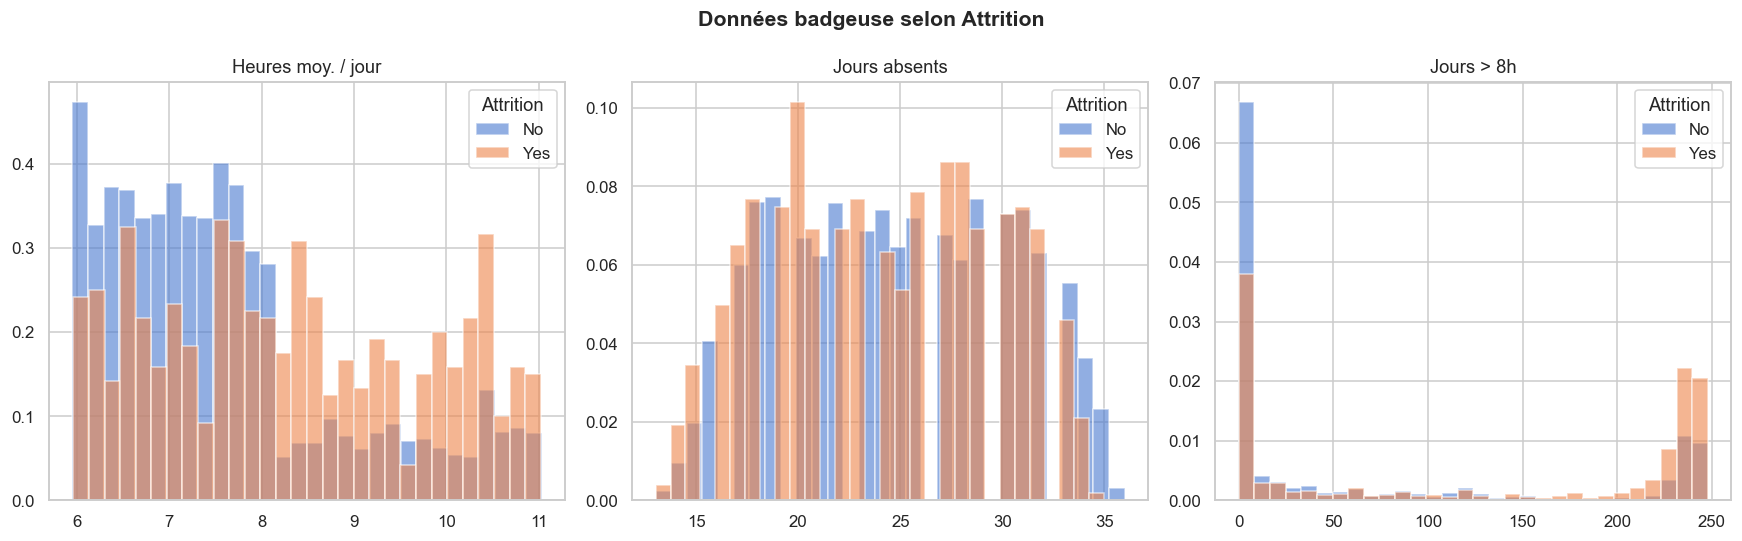

In [16]:
in_dt  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt = out_time.apply(pd.to_datetime, errors='coerce')

work_hours = (out_dt - in_dt).apply(lambda s: s.dt.total_seconds() / 3600)

badge_features = pd.DataFrame()
badge_features['EmployeeID']        = general['EmployeeID'].values
badge_features['avg_hours_per_day'] = work_hours.mean(axis=1).values
badge_features['std_hours_per_day'] = work_hours.std(axis=1).values
badge_features['days_absent']       = work_hours.isna().sum(axis=1).values
badge_features['days_over_8h']      = (work_hours > 8).sum(axis=1).values
badge_features['avg_arrival_hour']  = in_dt.apply(
    lambda col: col.dt.hour + col.dt.minute / 60).mean(axis=1).values

badge_merged = badge_features.merge(general[['EmployeeID', 'Attrition']], on='EmployeeID')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for i, (col, label) in enumerate(zip(
    ['avg_hours_per_day', 'days_absent', 'days_over_8h'],
    ['Heures moy. / jour', 'Jours absents', 'Jours > 8h']
)):
    for val, grp in badge_merged.groupby('Attrition'):
        axes[i].hist(grp[col].dropna(), bins=30, alpha=0.6, label=val, density=True)
    axes[i].set_title(label)
    axes[i].legend(title='Attrition')

plt.suptitle('Données badgeuse selon Attrition', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/badge_features_attrition.png', bbox_inches='tight')
plt.show()

## Ce qu'on retient

- 84% des employés restent, 16% partent - déséquilibre à traiter dans les modèles
- 3 colonnes constantes à supprimer (EmployeeCount, Over18, StandardHours)
- Quelques NA sur les variables de satisfaction et NumCompaniesWorked, rien de critique
- Le salaire, l'ancienneté, la satisfaction et les données de badgeage semblent les plus discriminants
- Le badgeage devra être résumé en indicateurs (heures moyennes, absences, etc.)

On passe au preprocessing.